СТАЙКО Р.Д. 2374


In [15]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scikit-learn


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler



In [17]:
# Загрузка данных (укажите правильный путь к файлу)
df = pd.read_csv('bldg-MC2.csv')

# Преобразуем время в понятный формат
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

# Фильтруем колонки только для F3_Z3 + время
target_cols = [col for col in df.columns if 'F_3_Z_3' in col]
my_data = df[['Date/Time'] + target_cols].copy()

# Упростим названия колонок для удобства
my_data.columns = [col.split(': ')[-1].replace('F_3_Z_3 ', '') for col in my_data.columns]

# Группируем по дням
# Берем среднее значение за каждый день
daily_data = my_data.groupby(my_data['Date/Time'].dt.date).mean()

daily_data = daily_data.head(14)

print("Данные за 14 дней подготовлены:")
print(daily_data.head())

Данные за 14 дней подготовлены:
                     Date/Time  Lights Power  Equipment Power  \
Date/Time                                                       
2016-05-31 2016-05-31 11:57:30    272.900839       258.625961   
2016-06-01 2016-06-01 11:57:30    220.419908       229.236642   
2016-06-02 2016-06-02 11:57:30    280.772978       263.034359   
2016-06-03 2016-06-03 11:57:30    283.397025       264.503825   
2016-06-04 2016-06-04 11:57:30      0.000000       105.801500   

            Thermostat Temp  Thermostat Heating Setpoint  \
Date/Time                                                  
2016-05-31        24.370040                    19.250000   
2016-06-01        24.349601                    19.250000   
2016-06-02        24.392114                    19.250000   
2016-06-03        24.360556                    20.420833   
2016-06-04        23.999997                    24.000000   

            Thermostat Cooling Setpoint   VAV REHEAT Damper Position  \
Date/Time          

In [23]:
# Рассчитываем статистики
stats = daily_data.describe().T[['mean', 'std', 'min', 'max']]
# Дисперсия
stats['variance'] = stats['std'] ** 2

print("\nСтатистика параметров:")
print(stats)

# Проверка корреляции
correlation = daily_data.corr()


Статистика параметров:
                                                          mean         std  \
Date/Time                        2016-06-06 23:57:29.999999488         NaN   
Lights Power                                        193.804579   128.22913   
Equipment Power                                     214.332058   71.808308   
Thermostat Temp                                      24.488468    0.771243   
Thermostat Heating Setpoint                          21.028125    2.524043   
Thermostat Cooling Setpoint                          24.129896    1.157789   
VAV REHEAT Damper Position                            0.719102    0.202316   
REHEAT COIL Power                                   380.347601  462.591466   
RETURN OUTLET CO2 Concentration                     614.361424  217.046565   
SUPPLY INLET Temperature                             15.643477     3.12503   
SUPPLY INLET Mass Flow Rate                           0.101517    0.028299   

                                       


1. Что мы выбросим:
    Thermostat Heating Setpoint и Thermostat Cooling Setpoint: по смыслу это параметры, задающиеся человеком - точки охлаждения и нагревания
    VAV REHEAT Damper Position: У этого параметра очень маленькая дисперсия (0.04).
    SUPPLY INLET Mass Flow Rate: Дисперсия ничтожна (0.0008). Ничего не будет видно


2. Что мы оставим:
    Эти параметры имеют хорошую вариативность (высокий std или variance), а значит, лица будут разными:

    Lights Power (Электричество: свет) —  std=128.

    Equipment Power (Электричество: розетки) — показывает активность техники.

    Thermostat Temp (Температура в зоне).

    REHEAT COIL Power (Мощность подогрева) — огромная дисперсия 213990

    RETURN OUTLET CO2 Concentration (Углекислый газ).

    SUPPLY INLET Temperature (Температура притока) — как система пыталась охладить/нагреть зону.
Остается 6 параметров, не очень детализированно но наглядно, остальные параметры не подходят для анализа как будто. Также я решил добавить дельту температуры - Delta Temperature = Thermostat Temp - SUPPLY INLET Temperature, мне кажется это полезный параметр для статистики.

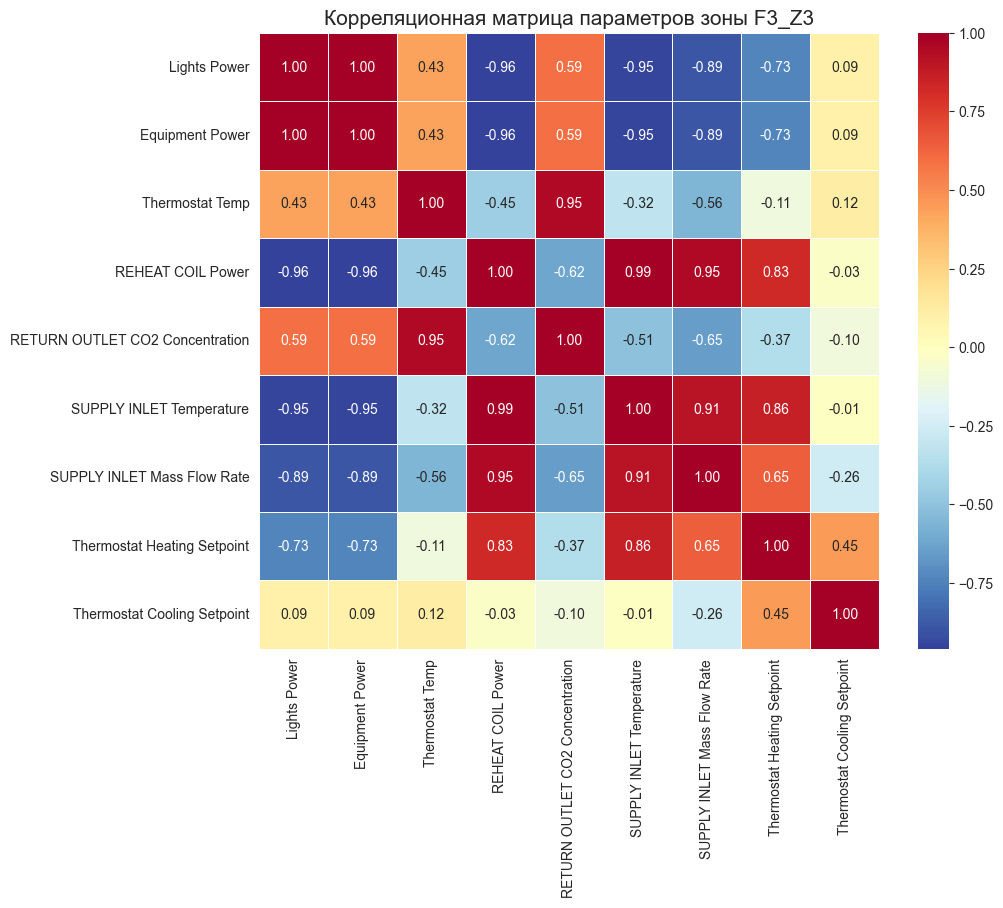

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

features_for_corr = [
    'Lights Power',
    'Equipment Power',
    'Thermostat Temp',
    'REHEAT COIL Power',
    'RETURN OUTLET CO2 Concentration',
    'SUPPLY INLET Temperature',
    'SUPPLY INLET Mass Flow Rate',
    'Thermostat Heating Setpoint',
    'Thermostat Cooling Setpoint'
]

# Считаем корреляцию Пирсона
corr_matrix = daily_data[features_for_corr].corr()

# Настройка визуализации
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0, fmt=".2f", linewidths=0.5)

plt.title('Корреляционная матрица параметров зоны F3_Z3', fontsize=15)
plt.show()

Видна 100% кореляция первых 2 параметров, чт логично. можно дать им симметричные параметры (брови)

In [32]:
# 1. Сначала причешем названия колонок в daily_data
daily_data.columns = daily_data.columns.str.strip()

# Добавляем новую колонку ΔT
daily_data["Delta Temp"] = (
    daily_data["Thermostat Temp"] - daily_data["SUPPLY INLET Temperature"]
)

# Обновляем список признаков
final_features = [
    'Lights Power',
    'Equipment Power',
    'Thermostat Temp',
    'REHEAT COIL Power',
    'RETURN OUTLET CO2 Concentration',
    'SUPPLY INLET Temperature',
    'Delta Temp'
]

# Нормализация
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()

norm_df = pd.DataFrame(
    scaler.fit_transform(daily_data[final_features]),
    columns=final_features,
    index=daily_data.index
)

norm_df = norm_df.clip(0, 1)

print(norm_df.head())

            Lights Power  Equipment Power  Thermostat Temp  REHEAT COIL Power  \
Date/Time                                                                       
2016-05-31      0.954128         0.954128         0.149162           0.000000   
2016-06-01      0.770642         0.770642         0.140923           0.000000   
2016-06-02      0.981651         0.981651         0.158059           0.000000   
2016-06-03      0.990826         0.990826         0.145339           0.196381   
2016-06-04      0.000000         0.000000         0.000000           0.951324   

            RETURN OUTLET CO2 Concentration  SUPPLY INLET Temperature  \
Date/Time                                                               
2016-05-31                         0.228093                  0.000279   
2016-06-01                         0.235788                  0.000292   
2016-06-02                         0.244003                  0.000276   
2016-06-03                         0.236340                  0.1966

In [68]:
import numpy as np
from matplotlib.patches import Circle, Polygon

def draw_chernoff_face(ax, x1, x2, x3, x4, x5, x6, x7):

    # ---- цвет лица ----
    green = np.array([0.6,0.85,0.6])
    yellow = np.array([1.0,0.95,0.5])
    red = np.array([0.95,0.55,0.55])

    if x5 < 0.5:
        t = x5*2
        face_color = green*(1-t) + yellow*t
    else:
        t = (x5-0.5)*2
        face_color = yellow*(1-t) + red*t

    face = Circle((0,0),1,color=face_color,ec="black")
    ax.add_patch(face)

    # ---- глаза ----
    eye_y = 0.3

    left_eye_size = 0.05 + x1*0.12
    right_eye_size = 0.05 + x2*0.12

    ax.add_patch(Circle((-0.35,eye_y),left_eye_size,color="white",ec="black"))
    ax.add_patch(Circle((0.35,eye_y),right_eye_size,color="white",ec="black"))

    # ---- зрачки  ----
    pupil = 0.02 + x3*0.05

    ax.add_patch(Circle((-0.35,eye_y),pupil,color="black"))
    ax.add_patch(Circle((0.35,eye_y),pupil,color="black"))

    # ---- нос ----
    nose_height = 0.15 + x4*0.6

    nose = Polygon([
        (-0.05,0.1),
        (0.05,0.1),
        (0,0.1-nose_height)
    ],closed=True,color="black")

    ax.add_patch(nose)

    # ---- рот ----
    mouth_x = np.linspace(-0.4,0.4,100)
    mouth_curve = (0.5 - x6) * 2.5
    mouth_y = -0.5 + mouth_curve*(mouth_x**2-0.16)

    ax.plot(mouth_x,mouth_y,color="black",linewidth=2)

    # ---- брови ----
    brow_y = 0.5

    tilt = max(0, x7 - 0.5) * 0.6

    ax.plot([-0.5, -0.2], [brow_y + tilt, brow_y - tilt], linewidth=2, color="black")
    ax.plot([0.2, 0.5], [brow_y - tilt, brow_y + tilt], linewidth=2, color="black")

    ax.set_xlim(-1.2,1.2)
    ax.set_ylim(-1.2,1.2)

    ax.set_aspect("equal")
    ax.axis("off")

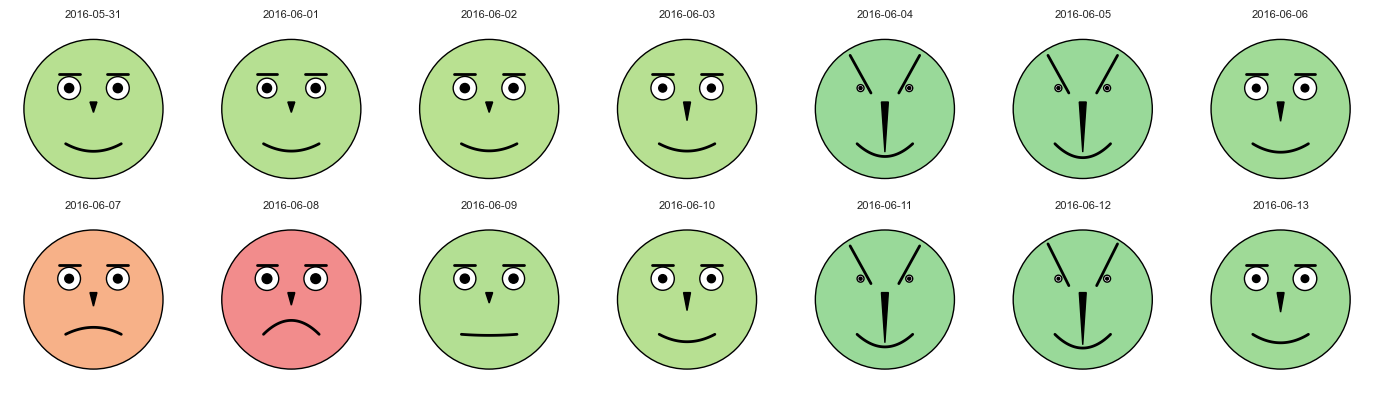

In [67]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,7, figsize=(14,4))

axes = axes.flatten()

for i, (date, row) in enumerate(norm_df.head(14).iterrows()):

    draw_chernoff_face(
        axes[i],
        row['Lights Power'],
        row['Equipment Power'],
        row['Delta Temp'],
        row['REHEAT COIL Power'],
        row['Thermostat Temp'],
        row['RETURN OUTLET CO2 Concentration'],
        row['SUPPLY INLET Temperature'],

    )

    axes[i].set_title(str(date), fontsize=8)

plt.tight_layout()
plt.show()

Тут явно видно выходные дни - система